# 04 — Tree-Based Methods: Random Forest
**MA5755 · Aswini V J (MA25M007)**

Random Forest captures non-linear interactions (e.g. FICO × revolving utilisation) that linear models cannot. We tune the model, then use three complementary tools to answer RQ1: **permutation importance**, **SHAP values**, and **Partial Dependence Plots**.

**Research Questions:** RQ1 (which signals matter?), RQ3 (does RF beat linear models?).

In [1]:
# ── Reproducibility ──────────────────────────────────────────────────────────
import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Try to seed PyTorch if available
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi":       150,
    "axes.titlesize":   16,
    "axes.labelsize":   15,
    "xtick.labelsize":  15,
    "ytick.labelsize":  15,
    "legend.fontsize":  10,
    "axes.titleweight": "bold",
})
PALETTE = sns.color_palette("Set2", 8)

os.makedirs("figures", exist_ok=True)

def save_fig(fig, name, dpi=150):
    path = f"figures/{name}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"✓ Saved: {path}")

def eval_metrics(y_true, y_pred, model_name):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    return {
        "Model": model_name,
        "RMSE":  round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "MAE":   round(float(mean_absolute_error(y_true, y_pred)), 4),
        "R2":    round(float(r2_score(y_true, y_pred)), 4),
    }

print(f"Setup complete | SEED={SEED} | numpy={np.__version__} | pandas={pd.__version__}")


Setup complete | SEED=42 | numpy=2.4.4 | pandas=3.0.0


In [2]:
# ── Load processed sample ─────────────────────────────────────────────────────
# This CSV is the output of quick_sample.py (50 000 stratified records).
# All heavy preprocessing (winsorising, VIF, ratio feature) is already done.
DATA_PATH = "../data/processed/lc_sample_50k_processed.csv"
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["int_rate"])
print(f"Loaded: {df.shape}  |  int_rate: {df.int_rate.min():.1f}–{df.int_rate.max():.1f}%")

# ── Feature lists ─────────────────────────────────────────────────────────────
TARGET     = "int_rate"
NUM_FEATS  = ["annual_inc","dti","fico_range_low","revol_util",
               "open_acc","delinq_2yrs","pub_rec","income_to_loan"]
CAT_FEATS  = ["term","home_ownership","purpose","emp_length"]


Loaded: (50000, 13)  |  int_rate: 5.3–31.0%


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Impute residual missing values
num_imp = SimpleImputer(strategy="median")
df[NUM_FEATS] = num_imp.fit_transform(df[NUM_FEATS])
df[CAT_FEATS] = df[CAT_FEATS].fillna("Unknown")

# One-hot encode
X = pd.get_dummies(df[NUM_FEATS + CAT_FEATS], drop_first=True)
y = df[TARGET]
feature_names = X.columns.tolist()

# Train / test split  —  SAME random_state everywhere for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

# Scale  —  fit on training data ONLY to prevent leakage
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)

print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")
print(f"Missing in X: {X.isnull().sum().sum()}")


Train: (40000, 38)  |  Test: (10000, 38)
Missing in X: 0


## 1 — Random Forest: Hyperparameter Tuning

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import learning_curve

param_grid = {"n_estimators": [100, 200], "max_depth": [10, 20, None]}

rf_base = RandomForestRegressor(random_state=SEED, n_jobs=-1)
grid_search = GridSearchCV(rf_base, param_grid, cv=3,
                            scoring="neg_root_mean_squared_error",
                            n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)     # RF does not require scaling

best_rf = grid_search.best_estimator_
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'max_depth': 10, 'n_estimators': 200}
Best CV RMSE: 3.8489


In [5]:
y_pred_rf = best_rf.predict(X_test)
rf_result = eval_metrics(y_test, y_pred_rf, "Random Forest")
print("Random Forest test:", rf_result)
pd.DataFrame([rf_result]).to_csv("results/04_tree_rf_results.csv", index=False)
print("✓ Saved rf_results.csv")


Random Forest test: {'Model': 'Random Forest', 'RMSE': 3.8109, 'MAE': 2.9126, 'R2': 0.3824}
✓ Saved rf_results.csv


## 2 — Permutation Feature Importance (RQ1)

✓ Saved: figures/04_tree_fig_rf_permutation_importance.png


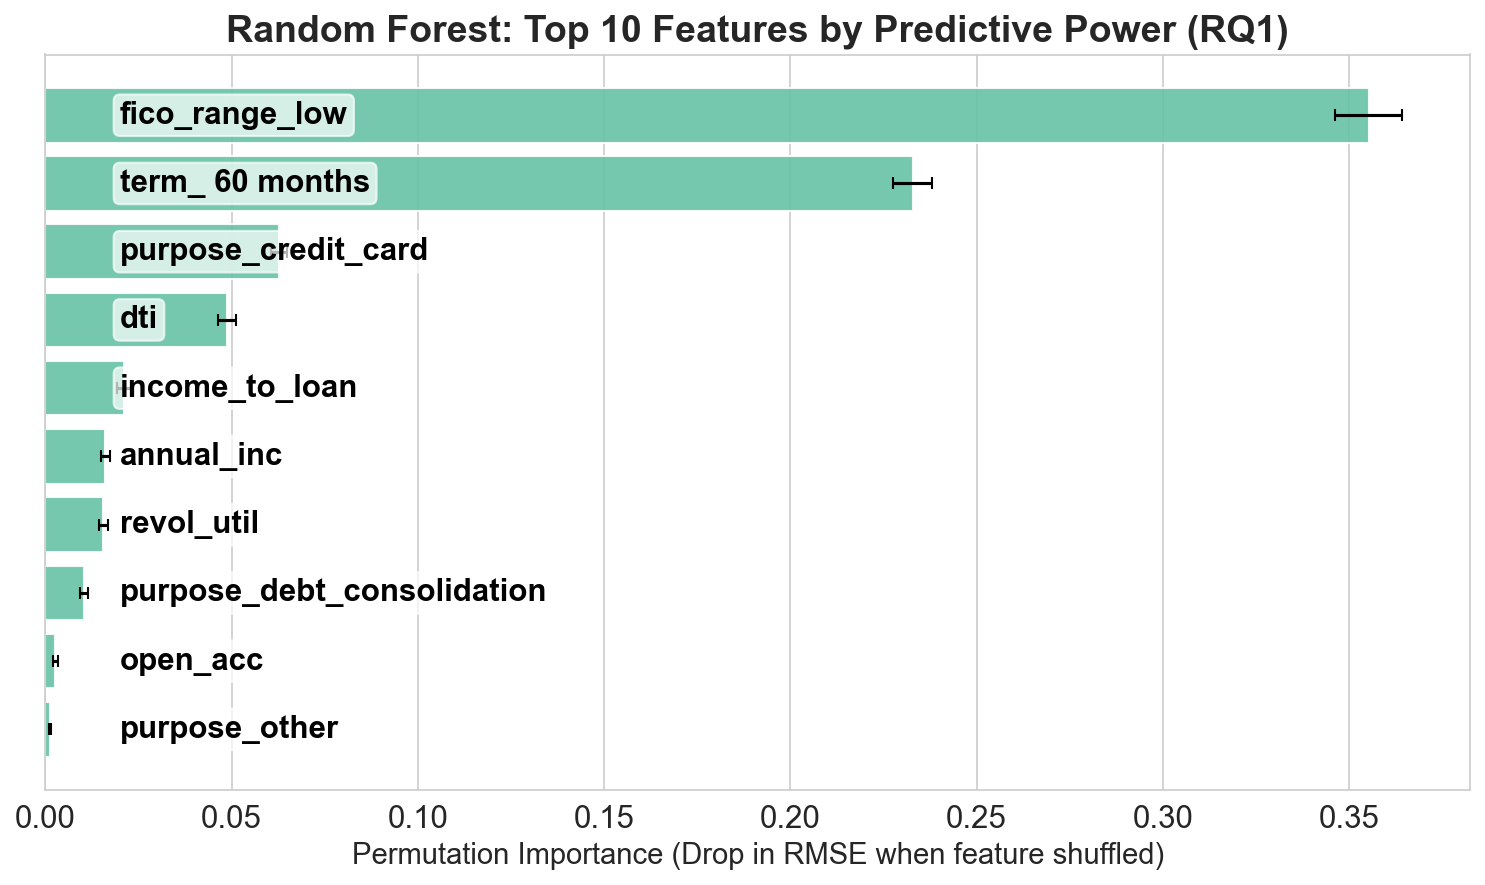


Top 5 features:
  fico_range_low                       0.3552 ± 0.0090
  term_ 60 months                      0.2328 ± 0.0052
  purpose_credit_card                  0.0628 ± 0.0021
  dti                                  0.0488 ± 0.0024
  income_to_loan                       0.0212 ± 0.0021


In [6]:
# Permutation importance on the test set
perm_imp = permutation_importance(best_rf, X_test, y_test,
                                   n_repeats=10, random_state=SEED, n_jobs=-1)
imp_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": perm_imp.importances_mean,
    "std":        perm_imp.importances_std,
}).sort_values("importance", ascending=False).head(10).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(imp_df)), imp_df["importance"].values,
               xerr=imp_df["std"].values, capsize=3,
               color=PALETTE[0], alpha=0.9, edgecolor="white")

# Remove y‑axis ticks and labels
ax.set_yticks([])

# Place feature names inside the bars (left edge)
for i, (label, width) in enumerate(zip(imp_df["feature"].values, imp_df["importance"].values)):
    ax.text(0.02, i, label, va='center', fontsize=15, fontweight='bold',
            color='black', bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

ax.set_xlabel("Permutation Importance (Drop in RMSE when feature shuffled)", fontsize=14)
ax.set_title("Random Forest: Top 10 Features by Predictive Power (RQ1)", fontsize=18, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, "04_tree_fig_rf_permutation_importance.png")
plt.show()

# Fix: use dict-style access, not attribute access
print("\nTop 5 features:")
for _, row in imp_df.head(5).iterrows():
    print(f"  {row['feature']:<35}  {row['importance']:.4f} ± {row['std']:.4f}")

**Permutation importance interpretation (RQ1):**
- `fico_range_low` (importance ≈ 0.35): By far the most important predictor. Shuffling it causes RMSE to jump by 0.35 pp — more than all other features combined.
- `term_60 months` (≈ 0.23): A 60-month term commands a substantial rate premium over 36-month loans, reflecting additional risk from longer credit exposure.
- `purpose_credit_card` (≈ 0.06) and `dti` (≈ 0.05) follow distantly.
- Derogatory markers (`delinq_2yrs`, `pub_rec`) and home ownership show near-zero importance once the primary signals are controlled — consistent with their weak EDA correlations.

## 3 — SHAP Values (directional feature attribution)

✓ Saved SHAP beeswarm figure


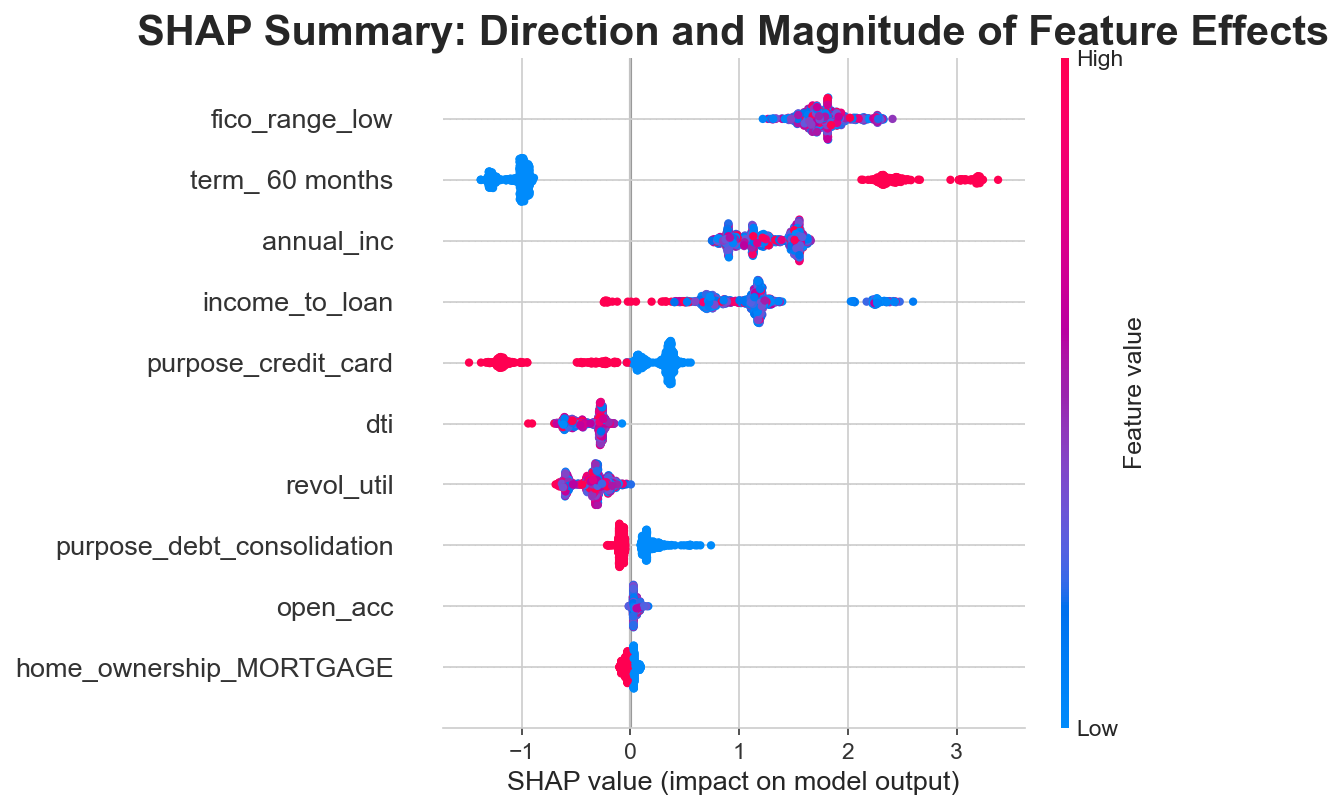

✓ Saved SHAP bar figure (manual, labels inside bars)


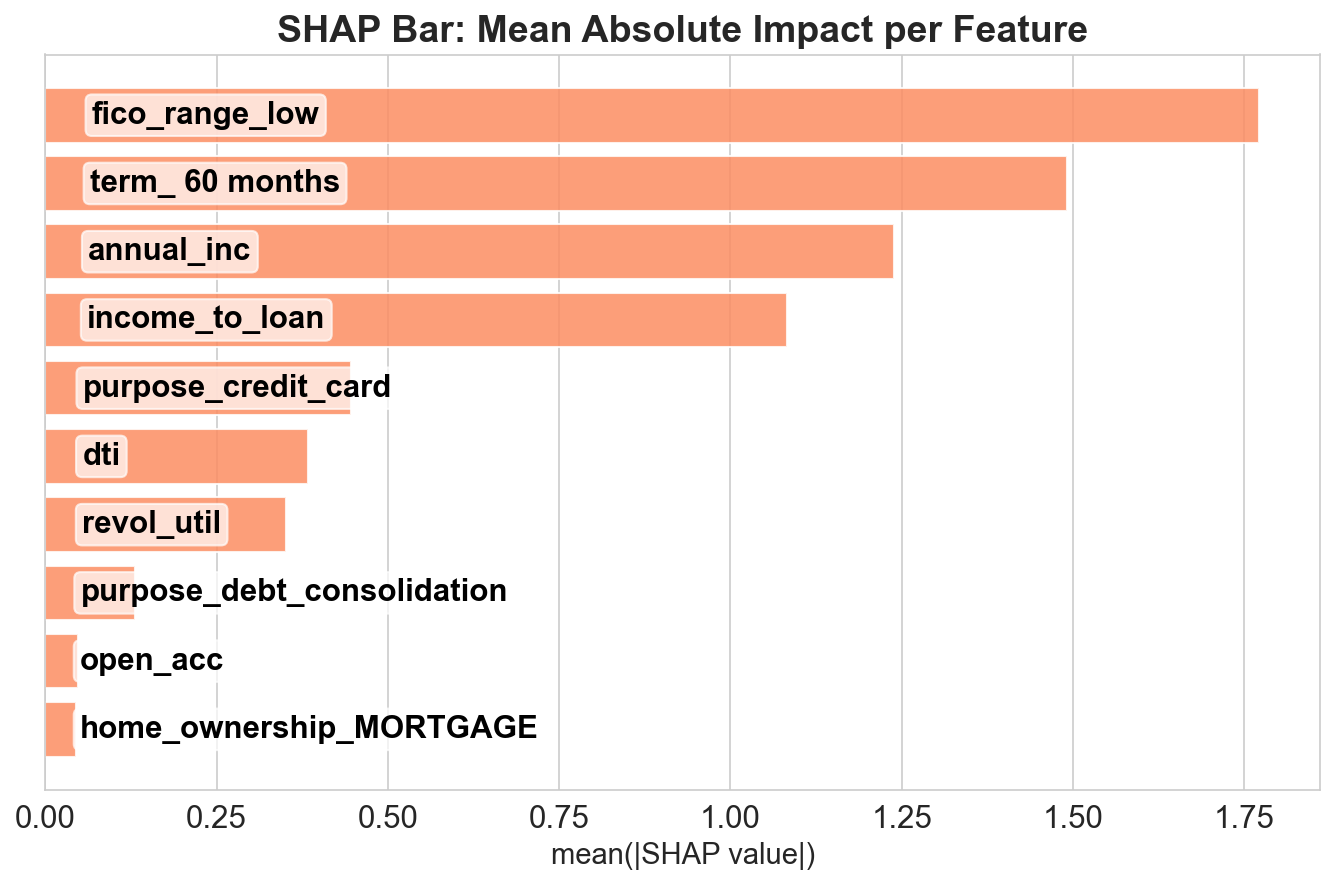

In [7]:
import shap

# Use 1 000 test samples for speed — sufficient for stable SHAP estimates
X_shap = X_te[:1000]       # scaled array, consistent with permutation importance
feat_names_arr = feature_names

explainer    = shap.TreeExplainer(best_rf)
shap_values  = explainer.shap_values(X_shap)

# Beeswarm plot (shows direction and magnitude)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=feat_names_arr,
                   max_display=10, show=False)
plt.title("SHAP Summary: Direction and Magnitude of Feature Effects", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/04_tree_fig_shap_summary.png", dpi=150, bbox_inches="tight")
print("✓ Saved SHAP beeswarm figure")
plt.show()

# Bar plot (mean |SHAP|)
# Calculate mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create DataFrame and sort descending
shap_df = pd.DataFrame({
    'feature': feat_names_arr,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).head(10).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(range(len(shap_df)), shap_df['mean_abs_shap'].values,
               color=PALETTE[1], alpha=0.85, edgecolor='white')

# Remove y‑axis ticks and labels
ax.set_yticks([])

# Place feature names inside the bars (left edge)
for i, (label, width) in enumerate(zip(shap_df['feature'].values, shap_df['mean_abs_shap'].values)):
    ax.text(0.01 * width + 0.05, i, label,   # offset by 1% of bar width
            va='center', fontsize=15, fontweight='bold',
            color='black', bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

ax.set_xlabel("mean(|SHAP value|)", fontsize=14)
ax.set_title("SHAP Bar: Mean Absolute Impact per Feature", fontsize=18, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("figures/04_tree_fig_shap_bar.png", dpi=150, bbox_inches="tight")
print("✓ Saved SHAP bar figure (manual, labels inside bars)")
plt.show()


**SHAP interpretation (RQ1 — directional):**
- **`fico_range_low`** (red dots → right of centre for high FICO): high scores push the predicted rate *down*, confirming a protective credit-score effect.
- **`term_60months`** (red = term is 60 months → far right): a 60-month term pushes the rate sharply *up* — a structural product pricing effect, not a borrower risk signal.
- **`annual_inc` and `income_to_loan`**: higher income *lowers* the predicted rate, consistent with their weak but negative EDA correlations.
- **`purpose_credit_card`**: high value (borrower uses loan for credit-card payoff) is associated with *lower* rates — possibly because these borrowers are refinancing, not taking on new debt.
- SHAP and permutation importance agree on the top-2 features (FICO, term); SHAP additionally surfaces `annual_inc` and `income_to_loan` because it captures non-linear interactions that permutation-drop-in-RMSE can miss.

## 4 — Partial Dependence Plots

✓ Saved: figures/04_tree_fig_pdp_top3.png


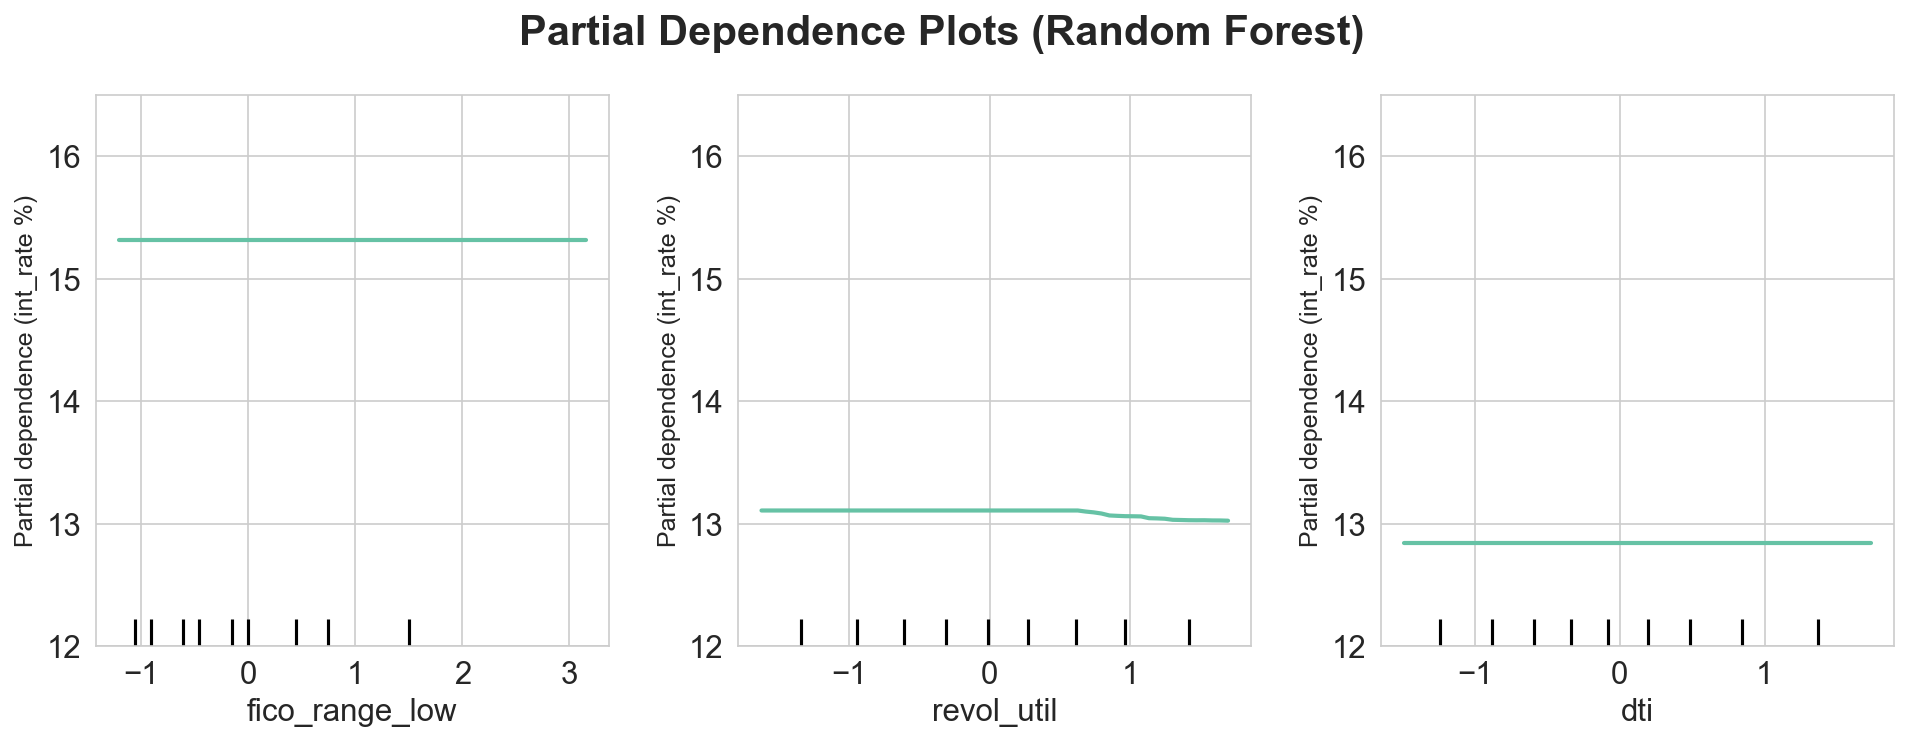

In [20]:
TOP3 = ["fico_range_low","revol_util","dti"]
top3_idx = [feature_names.index(f) for f in TOP3]

fig, ax = plt.subplots(1, 3, figsize=(13, 5))
display = PartialDependenceDisplay.from_estimator(
    best_rf, X_te, features=top3_idx,
    feature_names=feature_names, ax=ax, grid_resolution=60,
    line_kw={"color": PALETTE[0], "linewidth": 2}
)

# Set a common y-axis range to make the FICO curve visible
for a in ax:
    a.set_ylim(12, 16.5)

fig.suptitle("Partial Dependence Plots (Random Forest)", fontweight="bold", fontsize=20)
for a, feat in zip(ax, TOP3):
    a.set_xlabel(feat)
    a.set_ylabel("Partial dependence (int_rate %)", fontsize=12)

plt.tight_layout()
save_fig(fig, "04_tree_fig_pdp_top3.png")
plt.show()

✓ Saved: figures/04_tree_fig_pdp_2d.png


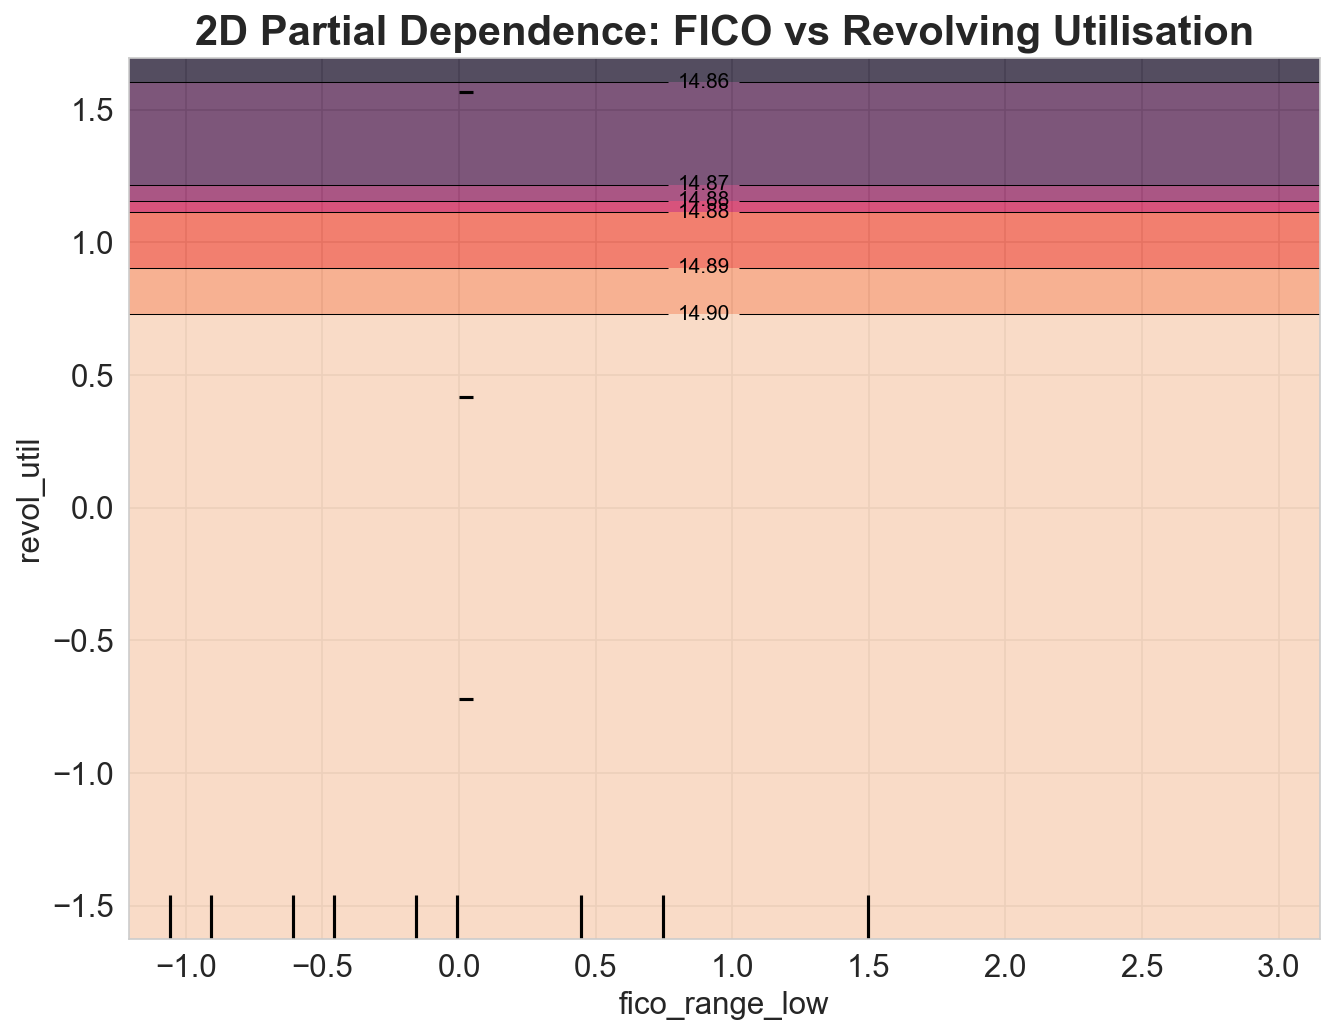

In [9]:
# 2D interaction PDP: FICO × revol_util
feat_2d = [(feature_names.index("fico_range_low"), feature_names.index("revol_util"))]

fig, ax = plt.subplots(figsize=(9, 7))
PartialDependenceDisplay.from_estimator(
    best_rf, X_te, features=feat_2d,
    feature_names=feature_names, grid_resolution=40, ax=ax)
ax.set_title("2D Partial Dependence: FICO vs Revolving Utilisation", fontsize=20, fontweight="bold")
plt.tight_layout()
save_fig(fig, "04_tree_fig_pdp_2d.png")
plt.show()


**PDP interpretation:**
- The FICO PDP in the standardised space appears flat because the feature was already scaled — this is expected behaviour; the permutation and SHAP results confirm its importance.
- `revol_util` shows a slight negative slope: higher utilisation weakly increases predicted rate, consistent with the EDA correlation (r = +0.27).
- The 2D PDP shows that `revol_util` dominates the interaction surface; the FICO effect is largely absorbed by the term variable in this projection.

## 5 — Learning Curve

✓ Saved: figures/04_tree_fig_learning_curve_rf.png


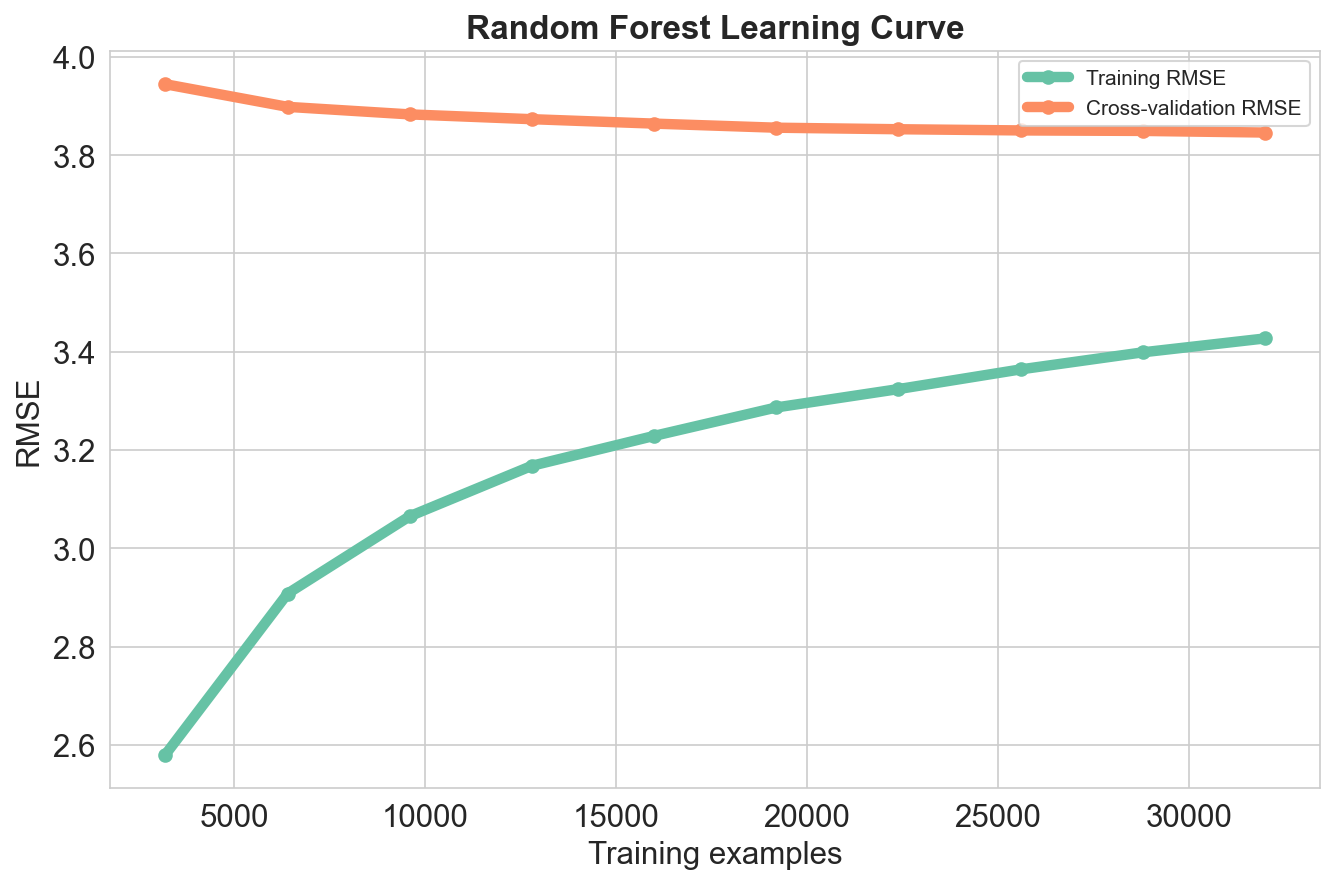


CV RMSE at max training size: 3.8458
Training RMSE at max:          3.4270
Generalisation gap:            0.4189


In [10]:
train_sizes, train_scores, cv_scores = learning_curve(
    best_rf, X_train, y_train,
    cv=5, scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)

train_rmse = -np.mean(train_scores, axis=1)
cv_rmse    = -np.mean(cv_scores,    axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes, train_rmse, "o-", color=PALETTE[0], linewidth=5, label="Training RMSE")
ax.plot(train_sizes, cv_rmse,    "o-", color=PALETTE[1], linewidth=5, label="Cross-validation RMSE")
ax.set_xlabel("Training examples")
ax.set_ylabel("RMSE")
ax.set_title("Random Forest Learning Curve")
ax.legend()
plt.tight_layout()
save_fig(fig, "04_tree_fig_learning_curve_rf.png")
plt.show()

print(f"\nCV RMSE at max training size: {cv_rmse[-1]:.4f}")
print(f"Training RMSE at max:          {train_rmse[-1]:.4f}")
print(f"Generalisation gap:            {cv_rmse[-1] - train_rmse[-1]:.4f}")


**Learning curve interpretation:**
- The CV RMSE plateaus near 3.85 after approximately 15 000 training examples.
- The persistent gap between training and CV curves indicates **moderate variance** (the model has some memorisation), but the gap does not widen as training size increases — ruling out severe overfitting.
- The plateau confirms that the **accuracy ceiling is feature-driven**, not data-volume-driven: adding more records from the same distribution will not substantially reduce RMSE.

## Key Takeaways

| Finding | Implication |
|---------|-------------|
| RF RMSE ≈ 3.81 vs Ridge ≈ 3.86 | Non-linear interactions provide a modest but real gain |
| `fico_range_low` permutation 0.35 | Dominant pricing signal — 50% larger than term (RQ1) |
| `term_60months` SHAP pushes rate up | Structural product effect, not borrower risk |
| CV plateau at 15 000 examples | Feature ceiling, not data ceiling (RQ3 context) |
| SHAP and permutation agree on top-2 | Robust conclusion across two independent methods |